# Library

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn.functional as F
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Discrete Case

In the continuous case, the PINN enforces the Black-Scholes PDE:
$$V_t + \frac{1}{2}\sigma^2 S^2 V_{SS} + r S V_S - r V = 0$$

In the **discrete case**, we replace this PDE with the Cox-Ross-Rubinstein (CRR) binomial recursion:
$$V(S, t_k) = e^{-r\Delta t}\left[p\, V(S u, t_{k+1}) + (1-p)\, V(S d, t_{k+1})\right]$$

where $\Delta t = T/N$ and the CRR parameters are:
$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = e^{-\sigma\sqrt{\Delta t}}, \quad p = \frac{e^{r\Delta t} - d}{u - d}$$

The PINN learns $V(S, t_k)$ at the discrete time grid $\{t_k = k\Delta t\}_{k=0}^{N}$ without needing any autodifferentiation — the residual is purely algebraic.

## Black-Scholes (Exact reference for comparison)

In [2]:
class BlackScholes:
    def __init__(self, r, sigma):
        self.r = r
        self.sigma = sigma

    def norm_cdf(self, x):
        return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

    def price(self, S, K, t, T, option_type="call"):
        tau = T - t
        eps = 1e-12

        tau_safe = torch.clamp(tau, min=eps)
        S_safe = torch.clamp(S, min=eps)

        d1 = (torch.log(S_safe / K) + (self.r + 0.5 * self.sigma**2) * tau_safe
             ) / (self.sigma * torch.sqrt(tau_safe))
        d2 = d1 - self.sigma * torch.sqrt(tau_safe)

        if option_type == "call":
            price = (S_safe * self.norm_cdf(d1) - K * torch.exp(-self.r * tau_safe) * self.norm_cdf(d2))
            payoff = torch.maximum(S - K, torch.zeros_like(S))
        elif option_type == "put":
            price = (K * torch.exp(-self.r * tau_safe) * self.norm_cdf(-d2) - S_safe * self.norm_cdf(-d1))
            payoff = torch.maximum(K - S, torch.zeros_like(S))
        else:
            raise ValueError("option_type must be 'call' or 'put'")

        return torch.where(tau <= eps, payoff, price)

## Binomial Tree (CRR) — Exact Discrete Reference

The CRR binomial tree prices a European option by backward induction from $t = T$ to $t = 0$.

In [3]:
class BinomialTree:
    def __init__(self, r, sigma, N):
        self.r = r
        self.sigma = sigma
        self.N = N

    def price(self, S0, K, T, option_type="call"):
        """
        Price a European option starting at price S0 at t=0.
        """
        dt = T / self.N
        u = math.exp(self.sigma * math.sqrt(dt))
        d = math.exp(-self.sigma * math.sqrt(dt))
        p = (math.exp(self.r * dt) - d) / (u - d)
        disc = math.exp(-self.r * dt)

        # Terminal stock prices at each node
        j = np.arange(self.N + 1)
        ST = S0 * (u ** (self.N - j)) * (d ** j)

        if option_type == "call":
            V = np.maximum(ST - K, 0.0)
        else:
            V = np.maximum(K - ST, 0.0)

        # Backward induction
        for _ in range(self.N):
            V = disc * (p * V[:-1] + (1 - p) * V[1:])

        return float(V[0])

    def price_at_step(self, S, K, T, step_k, option_type="call"):
        """
        Price a European option starting at price S at time t_k = step_k * dt.
        Equivalent to pricing with remaining time T - t_k.
        """
        tau = T - step_k * (T / self.N)
        if tau < 1e-12:
            if option_type == "call":
                return max(S - K, 0.0)
            else:
                return max(K - S, 0.0)

        steps_remaining = self.N - step_k
        dt = T / self.N
        u = math.exp(self.sigma * math.sqrt(dt))
        d = math.exp(-self.sigma * math.sqrt(dt))
        p = (math.exp(self.r * dt) - d) / (u - d)
        disc = math.exp(-self.r * dt)

        j = np.arange(steps_remaining + 1)
        ST = S * (u ** (steps_remaining - j)) * (d ** j)

        if option_type == "call":
            V = np.maximum(ST - K, 0.0)
        else:
            V = np.maximum(K - ST, 0.0)

        for _ in range(steps_remaining):
            V = disc * (p * V[:-1] + (1 - p) * V[1:])

        return float(V[0])

    def price_grid(self, S_values, K, T, step_k=0, option_type="call"):
        """Price for a vector of S values at time step step_k."""
        return np.array([self.price_at_step(s, K, T, step_k, option_type) for s in S_values])

## PINN Class (Discrete — Under CRR Binomial Framework)

The key difference with the continuous PINN:
- **No autograd** needed: the residual is purely algebraic (no PDE derivatives)
- The "physics" constraint is the CRR backward recursion
- Training points are sampled at discrete time steps $t_k \in \{0, \Delta t, \ldots, T - \Delta t\}$

In [4]:
class PINN_BS_Discrete(nn.Module):
    def __init__(self,
                 K, r, sigma, T, N,
                 S_min, S_max,
                 hidden_layers,
                 activation_fun=nn.Tanh,
                 loss_weights=None):
        super().__init__()

        # B&S / CRR parameters
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.N = N
        self.dt = T / N

        # CRR binomial tree factors
        self.u = math.exp(sigma * math.sqrt(self.dt))
        self.d = math.exp(-sigma * math.sqrt(self.dt))
        self.p = (math.exp(r * self.dt) - self.d) / (self.u - self.d)
        self.disc = math.exp(-r * self.dt)

        # PDE range
        self.S_min = S_min
        self.S_max = S_max

        self.hidden_layers = hidden_layers
        self.activation_fun = activation_fun
        self.mse = nn.MSELoss()

        if loss_weights is None:
            loss_weights = {
                "recursion": 1.0,
                "terminal": 10.0,
                "boundary_S0": 1.0,
                "boundary_Smax": 1.0,
            }
        self.loss_weights = loss_weights

        # Network architecture (same as continuous case)
        layers = []
        layers.append(nn.Linear(2, hidden_layers[0]))
        layers.append(activation_fun())
        for i in range(len(hidden_layers) - 1):
            layers.append(nn.Linear(hidden_layers[i], hidden_layers[i + 1]))
            layers.append(activation_fun())
        layers.append(nn.Linear(hidden_layers[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, S, t):
        """
        Scale input (S, t) to [-1, 1] and return predicted option price V(S, t).
        """
        x = torch.cat([S, t], dim=1)
        x_scaled = torch.empty_like(x)
        x_scaled[:, 0:1] = 2.0 * (x[:, 0:1] - self.S_min) / (self.S_max - self.S_min) - 1.0
        x_scaled[:, 1:2] = 2.0 * (x[:, 1:2] / self.T) - 1.0
        return F.softplus(self.net(x_scaled))

    def crr_recursion_residual(self, S, t_k):
        """
        Compute the CRR backward recursion residual at (S, t_k):

            R(S, t_k) = V(S, t_k) - disc * [p * V(S*u, t_{k+1}) + (1-p) * V(S*d, t_{k+1})]

        No autograd needed: purely algebraic.
        """
        t_next = t_k + self.dt

        S_up = torch.clamp(S * self.u, self.S_min + 1e-6, self.S_max)
        S_down = torch.clamp(S * self.d, self.S_min + 1e-6, self.S_max)

        V_curr   = self.forward(S, t_k)
        V_up     = self.forward(S_up, t_next)
        V_down   = self.forward(S_down, t_next)

        V_target = self.disc * (self.p * V_up + (1.0 - self.p) * V_down)

        return V_curr - V_target

    def sample_training_points(self, N_rec, N_terminal, N_b):
        """
        Sample training points for the discrete PINN.

        N_rec      : recursion collocation points at random time steps k in {0, ..., N-1}
        N_terminal : terminal-condition points at t = T
        N_b        : boundary points at S=0 and S=S_max
        """
        device = next(self.parameters()).device
        eps = 1e-6

        # Recursion points: random S, random time step k in {0, ..., N-1}
        S_rec = torch.rand(N_rec, 1, device=device) * (self.S_max - eps) + eps
        k_rec = torch.randint(0, self.N, (N_rec, 1), device=device).float()
        t_rec = k_rec * self.dt

        # Terminal: t = T
        S_T = torch.rand(N_terminal, 1, device=device) * (self.S_max - self.S_min) + self.S_min
        t_T = torch.full((N_terminal, 1), self.T, device=device)

        # Boundary S = 0
        S_b0 = torch.zeros(N_b, 1, device=device)
        k_b0 = torch.randint(0, self.N + 1, (N_b, 1), device=device).float()
        t_b0 = k_b0 * self.dt

        # Boundary S = S_max
        S_b1 = torch.full((N_b, 1), self.S_max, device=device)
        k_b1 = torch.randint(0, self.N + 1, (N_b, 1), device=device).float()
        t_b1 = k_b1 * self.dt

        return S_rec, t_rec, S_T, t_T, S_b0, t_b0, S_b1, t_b1

    def compute_loss_from_data(self, data):
        """
        Compute the total PINN loss on a fixed dataset (required for L-BFGS).
        """
        S_rec, t_rec, S_T, t_T, S_b0, t_b0, S_b1, t_b1 = data

        # CRR recursion loss
        residual = self.crr_recursion_residual(S_rec, t_rec)
        loss_rec = self.mse(residual, torch.zeros_like(residual))

        # Terminal condition: V(S, T) = max(S - K, 0)
        V_pred_T = self.forward(S_T, t_T)
        V_true_T = torch.maximum(S_T - self.K, torch.zeros_like(S_T))
        loss_terminal = self.mse(V_pred_T, V_true_T)

        # Boundary S = 0: V(0, t) = 0
        V_pred_b0 = self.forward(S_b0, t_b0)
        loss_b0 = self.mse(V_pred_b0, torch.zeros_like(S_b0))

        # Boundary S = S_max: V(S_max, t) ≈ S_max - K*exp(-r*(T-t))  (continuous BS limit)
        V_pred_b1 = self.forward(S_b1, t_b1)
        V_true_b1 = S_b1 - self.K * torch.exp(-self.r * (self.T - t_b1))
        loss_b1 = self.mse(V_pred_b1, V_true_b1)

        loss = (
            self.loss_weights["recursion"]      * loss_rec
            + self.loss_weights["terminal"]     * loss_terminal
            + self.loss_weights["boundary_S0"]  * loss_b0
            + self.loss_weights["boundary_Smax"]* loss_b1
        )

        return loss, {
            "loss_rec":      loss_rec.item(),
            "loss_terminal": loss_terminal.item(),
            "loss_b0":       loss_b0.item(),
            "loss_b1":       loss_b1.item(),
        }

    def compute_loss(self, N_rec, N_terminal, N_b):
        data = self.sample_training_points(N_rec, N_terminal, N_b)
        return self.compute_loss_from_data(data)

## Initialization

In [5]:
torch.manual_seed(42)
np.random.seed(42)

# Black-Scholes / CRR parameters
K     = 100.0
r     = 0.05
sigma = 0.20
T     = 1.0
N     = 50       # number of discrete time steps

# Ranges
S_min = 0.0
S_max = 150.0

# Training sample sizes
N_rec      = 20000  # recursion collocation points
N_terminal = 2000   # payoff points at t = T
N_b        = 1000   # boundary points

# Network hyperparameters
hidden_layers  = [128, 128, 128, 128]
activation_fun = nn.Tanh

loss_weights = {
    "recursion":      1.0,
    "terminal":      10.0,
    "boundary_S0":    1.0,
    "boundary_Smax":  5.0,
}

lr     = 1e-3
epochs = 5000

# Reference models
bs  = BlackScholes(r, sigma)
crr = BinomialTree(r, sigma, N)

# Discrete PINN
model_d = PINN_BS_Discrete(
    K, r, sigma, T, N,
    S_min, S_max,
    hidden_layers,
    activation_fun,
    loss_weights
).to(device)

dt = T / N
print(f"Time step dt = {dt:.4f}")
print(f"CRR factors: u = {crr.u if hasattr(crr,'u') else math.exp(sigma*math.sqrt(dt)):.6f}, "
      f"d = {math.exp(-sigma*math.sqrt(dt)):.6f}, "
      f"p = {(math.exp(r*dt)-math.exp(-sigma*math.sqrt(dt)))/(math.exp(sigma*math.sqrt(dt))-math.exp(-sigma*math.sqrt(dt))):.6f}")

Time step dt = 0.0200
CRR factors: u = 1.028688, d = 0.972112, p = 0.510614


## Training + Optimization

In [6]:
optimizer = optim.Adam(model_d.parameters(), lr=lr)

pbar = tqdm(range(1, epochs + 1), desc="Training (Discrete)")
for epoch in pbar:
    optimizer.zero_grad()
    loss, parts = model_d.compute_loss(N_rec, N_terminal, N_b)
    loss.backward()
    optimizer.step()

    pbar.set_postfix(loss=f"{loss.item():.3e}")

    if epoch % 500 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | "
            f"Total {loss.item():.6e} | "
            f"Rec {parts['loss_rec']:.3e} | "
            f"Terminal {parts['loss_terminal']:.3e} | "
            f"S=0 {parts['loss_b0']:.3e} | "
            f"S=max {parts['loss_b1']:.3e}"
        )

# L-BFGS fine-tuning on a fixed dataset
fixed_data = model_d.sample_training_points(N_rec, N_terminal, N_b)

optimizer_lbfgs = torch.optim.LBFGS(
    model_d.parameters(),
    lr=1.0,
    max_iter=1000,
    max_eval=500,
    history_size=50,
    line_search_fn="strong_wolfe"
)

def closure():
    optimizer_lbfgs.zero_grad()
    loss, _ = model_d.compute_loss_from_data(fixed_data)
    loss.backward()
    return loss

optimizer_lbfgs.step(closure)

Training (Discrete):   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch     1 | Total 1.610945e+04 | Rec 8.925e-07 | Terminal 2.707e+02 | S=0 5.358e-01 | S=max 2.680e+03
Epoch   500 | Total 1.975014e+02 | Rec 5.708e-01 | Terminal 1.498e-01 | S=0 1.927e-40 | S=max 3.909e+01
Epoch  1000 | Total 4.096778e+00 | Rec 1.860e-01 | Terminal 3.006e-03 | S=0 0.000e+00 | S=max 7.761e-01
Epoch  1500 | Total 5.603601e-01 | Rec 8.742e-02 | Terminal 4.263e-03 | S=0 0.000e+00 | S=max 8.606e-02
Epoch  2000 | Total 2.035590e-01 | Rec 7.865e-02 | Terminal 2.079e-03 | S=0 0.000e+00 | S=max 2.082e-02
Epoch  2500 | Total 1.650496e-01 | Rec 7.114e-02 | Terminal 5.719e-03 | S=0 0.000e+00 | S=max 7.345e-03
Epoch  3000 | Total 1.840522e-01 | Rec 6.458e-02 | Terminal 9.575e-03 | S=0 0.000e+00 | S=max 4.744e-03
Epoch  3500 | Total 1.790291e-01 | Rec 5.950e-02 | Terminal 1.002e-02 | S=0 0.000e+00 | S=max 3.857e-03
Epoch  4000 | Total 1.098877e-01 | Rec 5.612e-02 | Terminal 4.591e-03 | S=0 0.000e+00 | S=max 1.572e-03
Epoch  4500 | Total 7.947566e-02 | Rec 6.015e-02 | Terminal 1.44

tensor(0.2395, device='cuda:0', grad_fn=<AddBackward0>)

## Evaluation

We compare the discrete PINN against:
1. The exact Black-Scholes formula (continuous limit)
2. The CRR binomial tree with $N=50$ steps (exact discrete reference)

In [7]:
model_d.eval()

nS = 200
S_grid = torch.linspace(S_min, S_max, nS, device=device).view(-1, 1)
t_zero = torch.zeros(nS, 1, device=device)  # evaluate at t = 0

with torch.no_grad():
    V_pinn = model_d(S_grid, t_zero).cpu().numpy().flatten()
    V_bs   = bs.price(S=S_grid, K=K, t=t_zero, T=T, option_type="call").cpu().numpy().flatten()

S_np = S_grid.cpu().numpy().flatten()
V_crr = crr.price_grid(S_np, K, T, step_k=0, option_type="call")

abs_err_vs_bs  = np.abs(V_pinn - V_bs)
abs_err_vs_crr = np.abs(V_pinn - V_crr)

def rel_l2(pred, ref):
    return np.linalg.norm(pred - ref) / (np.linalg.norm(ref) + 1e-12)

print("Evaluation at t=0 on S grid:")
print(f"vs BS  — Rel L2: {rel_l2(V_pinn, V_bs):.6e}  |  RMSE: {np.sqrt(np.mean(abs_err_vs_bs**2)):.6e}  |  Max: {abs_err_vs_bs.max():.6e}")
print(f"vs CRR — Rel L2: {rel_l2(V_pinn, V_crr):.6e}  |  RMSE: {np.sqrt(np.mean(abs_err_vs_crr**2)):.6e}  |  Max: {abs_err_vs_crr.max():.6e}")

Evaluation at t=0 on S grid:
vs BS  — Rel L2: 5.023308e-02  |  RMSE: 9.988849e-01  |  Max: 2.252621e+00
vs CRR — Rel L2: 5.020732e-02  |  RMSE: 9.983849e-01  |  Max: 2.256737e+00


## Single Cases

In [8]:
def compare_prices_table_discrete(model, bt, S_list, step_k=0):
    model.eval()
    t_val = step_k * (T / N)

    with torch.no_grad():
        S_tensor = torch.tensor([[float(s)] for s in S_list], device=device)
        t_tensor = torch.full_like(S_tensor, float(t_val))

        pinn_prices  = model(S_tensor, t_tensor).cpu().numpy().flatten()
        exact_bs     = bs.price(S=S_tensor, K=K, t=t_tensor, T=T, option_type="call").cpu().numpy().flatten()

    crr_prices = np.array([bt.price_at_step(s, K, T, step_k, "call") for s in S_list])

    df = pd.DataFrame({
        "S":              S_list,
        "t_k":            [t_val] * len(S_list),
        "PINN_price":     pinn_prices,
        "CRR_price":      crr_prices,
        "BS_exact_price": exact_bs,
        "Err_vs_CRR":     np.abs(pinn_prices - crr_prices),
        "Err_vs_BS":      np.abs(pinn_prices - exact_bs),
    })
    return df

S_values = [40, 60, 80, 90, 100, 110, 120, 140]
df = compare_prices_table_discrete(model_d, crr, S_values, step_k=0)
df.round(6)

,S,t_k,PINN_price,CRR_price,BS_exact_price,Err_vs_CRR,Err_vs_BS
0,40,0.0,0.000000,0.000007,0.000019,0.000007,0.000019
1,60,0.0,0.008099,0.047161,0.054438,0.039062,0.046339
2,80,0.0,2.897899,1.830257,1.859418,1.067642,1.038481
3,90,0.0,5.965152,5.081286,5.091221,0.883866,0.873931
4,100,0.0,11.105181,10.410692,10.450577,0.694489,0.654604
5,110,0.0,18.906898,17.685079,17.662949,1.221820,1.243950
6,120,0.0,27.992754,26.171499,26.169044,1.821255,1.823710
7,140,0.0,46.977913,45.101613,45.110603,1.876300,1.867310


## Graphs

### PINN vs CRR vs Black-Scholes at t = 0

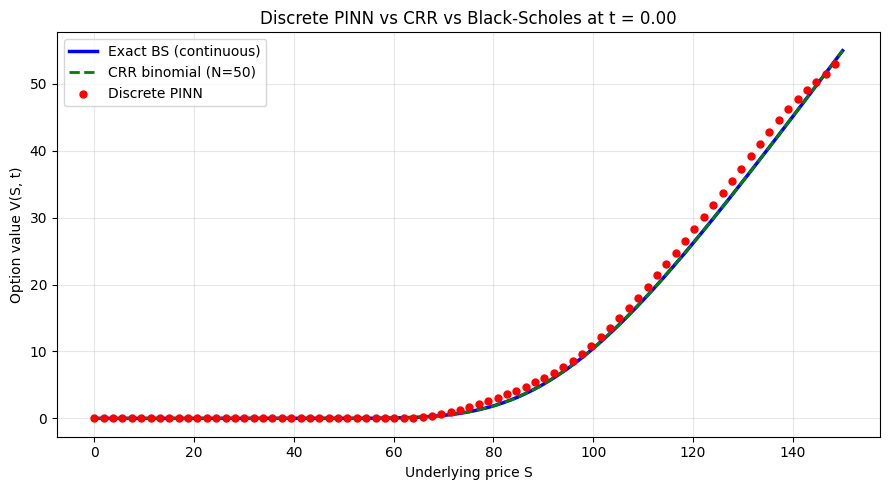

In [9]:
def plot_single_slice_discrete(model, bt, t_val=0.0, step_k=0, nS=400):
    model.eval()

    S_line = torch.linspace(S_min, S_max, nS, device=device).view(-1, 1)
    t_line = torch.full_like(S_line, t_val)

    with torch.no_grad():
        V_pinn = model(S_line, t_line).cpu().numpy().flatten()
        V_bs_  = bs.price(S=S_line, K=K, t=t_line, T=T, option_type="call").cpu().numpy().flatten()

    S_np   = S_line.cpu().numpy().flatten()
    V_crr_ = bt.price_grid(S_np, K, T, step_k=step_k, option_type="call")

    plt.figure(figsize=(9, 5))
    plt.plot(S_np, V_bs_,  color="blue",   linewidth=2.5, label="Exact BS (continuous)", zorder=2)
    plt.plot(S_np, V_crr_, color="green",  linewidth=2.0, linestyle="--", label=f"CRR binomial (N={N})", zorder=3)
    plt.scatter(S_np[::5], V_pinn[::5], color="red", s=25, label="Discrete PINN", zorder=4)
    plt.xlabel("Underlying price S")
    plt.ylabel("Option value V(S, t)")
    plt.title(f"Discrete PINN vs CRR vs Black-Scholes at t = {t_val:.2f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_single_slice_discrete(model_d, crr, t_val=0.0, step_k=0)

### Error Comparison: PINN vs CRR and PINN vs BS

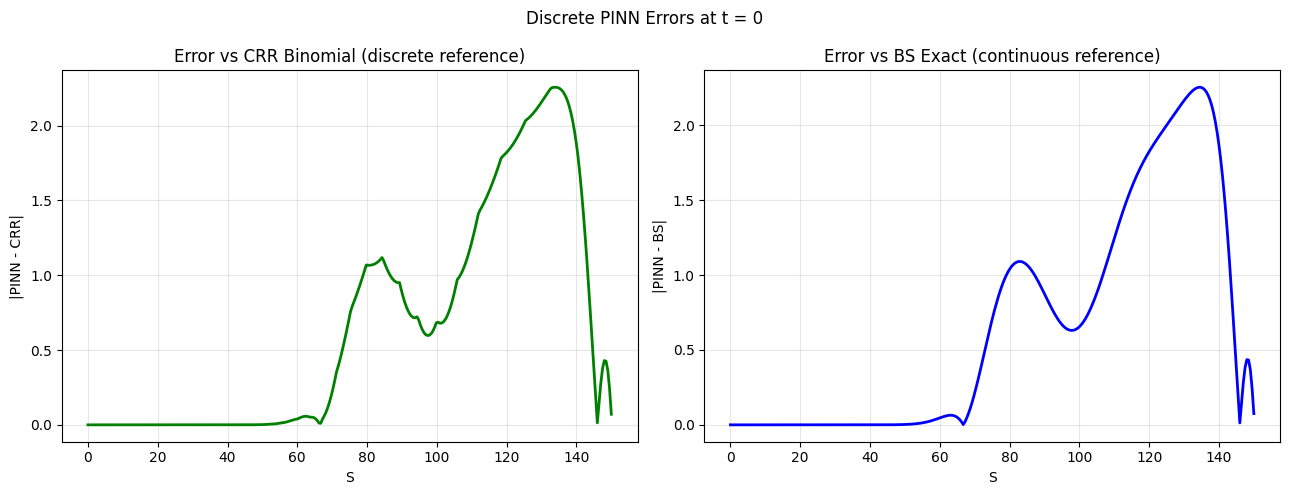

In [10]:
def plot_error_comparison(model, bt, nS=300):
    model.eval()

    S_line  = torch.linspace(S_min, S_max, nS, device=device).view(-1, 1)
    t_zero_ = torch.zeros(nS, 1, device=device)

    with torch.no_grad():
        V_pinn_ = model(S_line, t_zero_).cpu().numpy().flatten()
        V_bs_   = bs.price(S=S_line, K=K, t=t_zero_, T=T, option_type="call").cpu().numpy().flatten()

    S_np_   = S_line.cpu().numpy().flatten()
    V_crr_  = bt.price_grid(S_np_, K, T, step_k=0, option_type="call")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(S_np_, np.abs(V_pinn_ - V_crr_), color="green", linewidth=2)
    axes[0].set_xlabel("S")
    axes[0].set_ylabel("|PINN - CRR|")
    axes[0].set_title("Error vs CRR Binomial (discrete reference)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(S_np_, np.abs(V_pinn_ - V_bs_), color="blue", linewidth=2)
    axes[1].set_xlabel("S")
    axes[1].set_ylabel("|PINN - BS|")
    axes[1].set_title("Error vs BS Exact (continuous reference)")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Discrete PINN Errors at t = 0")
    plt.tight_layout()
    plt.show()

plot_error_comparison(model_d, crr)

### Heatmap of PINN Price over (S, t) Grid

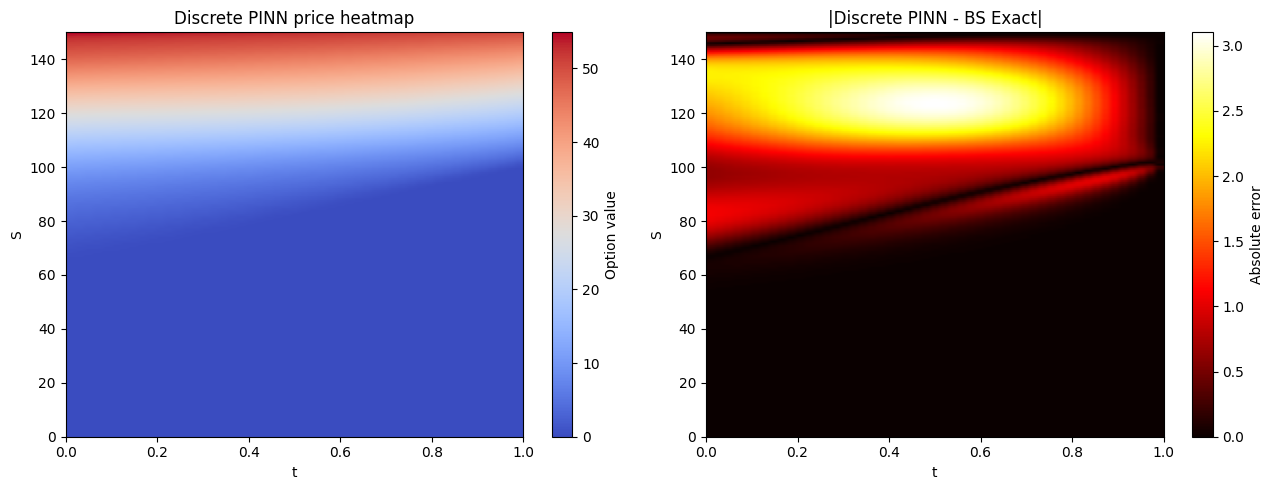

In [11]:
def plot_discrete_heatmap(model, nS=200):
    model.eval()

    t_steps = torch.tensor([k * (T / N) for k in range(N + 1)], device=device)  # all discrete steps
    S_vals  = torch.linspace(S_min, S_max, nS, device=device)

    SS, TT = torch.meshgrid(S_vals, t_steps, indexing="ij")
    S_test = SS.reshape(-1, 1)
    t_test = TT.reshape(-1, 1)

    with torch.no_grad():
        V_pinn_ = model(S_test, t_test).reshape(nS, N + 1).cpu().numpy()

    S_np_ = S_vals.cpu().numpy()
    t_np_ = t_steps.cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # PINN heatmap
    im0 = axes[0].imshow(
        V_pinn_,
        extent=[t_np_.min(), t_np_.max(), S_np_.min(), S_np_.max()],
        origin="lower", aspect="auto", cmap="coolwarm"
    )
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("S")
    axes[0].set_title("Discrete PINN price heatmap")
    plt.colorbar(im0, ax=axes[0], label="Option value")

    # BS reference heatmap (continuous)
    with torch.no_grad():
        V_bs_ = bs.price(S=S_test, K=K, t=t_test, T=T, option_type="call").reshape(nS, N + 1).cpu().numpy()

    im1 = axes[1].imshow(
        np.abs(V_pinn_ - V_bs_),
        extent=[t_np_.min(), t_np_.max(), S_np_.min(), S_np_.max()],
        origin="lower", aspect="auto", cmap="hot"
    )
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("S")
    axes[1].set_title("|Discrete PINN - BS Exact|")
    plt.colorbar(im1, ax=axes[1], label="Absolute error")

    plt.tight_layout()
    plt.show()

plot_discrete_heatmap(model_d)

### Convergence: CRR vs BS as N increases

As $N \to \infty$, the CRR binomial tree converges to the continuous Black-Scholes price.

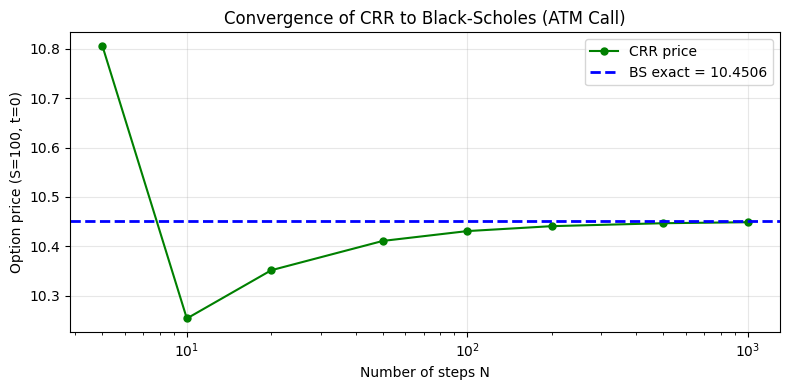

Black-Scholes exact (ATM, t=0): 10.450577
CRR N=50:   10.410692
CRR N=1000: 10.448584


In [12]:
S_test_scalar = torch.tensor([[100.0]], device=device)
t_test_scalar = torch.tensor([[0.0]], device=device)

bs_price_atm = bs.price(S=S_test_scalar, K=K, t=t_test_scalar, T=T, option_type="call").item()

N_values = [5, 10, 20, 50, 100, 200, 500, 1000]
crr_prices_atm = []
for n in N_values:
    bt_tmp = BinomialTree(r, sigma, n)
    crr_prices_atm.append(bt_tmp.price(100.0, K, T, "call"))

plt.figure(figsize=(8, 4))
plt.plot(N_values, crr_prices_atm, "go-", label="CRR price", markersize=5)
plt.axhline(bs_price_atm, color="blue", linestyle="--", linewidth=2, label=f"BS exact = {bs_price_atm:.4f}")
plt.xlabel("Number of steps N")
plt.ylabel("Option price (S=100, t=0)")
plt.title("Convergence of CRR to Black-Scholes (ATM Call)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale("log")
plt.tight_layout()
plt.show()

print(f"Black-Scholes exact (ATM, t=0): {bs_price_atm:.6f}")
print(f"CRR N=50:   {crr_prices_atm[N_values.index(50)]:.6f}")
print(f"CRR N=1000: {crr_prices_atm[-1]:.6f}")